In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
from torch_geometric.utils import add_self_loops
from torch_geometric.nn import MessagePassing
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

In [3]:
print('Total number of training nodes before split: ',data.train_mask.sum())
print('Total number of training nodes before split: ',data.test_mask.sum())
print('Total number of training nodes before split: ',data.val_mask.sum())


Total number of training nodes before split:  tensor(140)
Total number of training nodes before split:  tensor(1000)
Total number of training nodes before split:  tensor(500)


In [4]:
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [5]:
num_nodes = data.num_nodes
indices = torch.randperm(num_nodes)
train_size = int(0.7 * num_nodes)
val_size = int(0.15 * num_nodes)
test_size = num_nodes - train_size - val_size
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[indices[:train_size]] = True
val_mask[indices[train_size:train_size+val_size]] = True
test_mask[indices[train_size+val_size:]] = True
data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

print("Train nodes:", train_mask.sum().item())
print("Validation nodes:", val_mask.sum().item())
print("Test nodes:", test_mask.sum().item())

Train nodes: 1895
Validation nodes: 406
Test nodes: 407


In [6]:
class NeutrosophicFuzzification(nn.Module):
    def __init__(self, alpha=0.5, beta=2.0):
        super().__init__()
        self.alpha = alpha
        self.beta = beta

    def forward(self, x):
        mean = x.mean(dim=0, keepdim=True)
        std = x.std(dim=0, keepdim=True) + 1e-6

        T = torch.exp(-((x - mean)**2) / (2 * std**2))
        F_ns = 1 - torch.exp(-((x - mean)**2) / (2 * (self.alpha * std)**2))
        I = 1 - torch.exp(-((x - mean)**2) / (2 * (self.beta * std)**2))

        combined = torch.stack([T, I, F_ns], dim=2)
        return combined

In [7]:
class NGNNLayer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')

        self.in_channels = in_channels
        self.out_channels = out_channels
        
        # Single linear: [in_channels * 3] -> [out_channels * 3]
        self.linear = nn.Linear(in_channels * 3, out_channels * 3)

    def forward(self, combined, edge_index):
        # combined: [num_nodes, in_channels, 3]
        num_nodes = combined.size(0)
        
        edge_index, _ = add_self_loops(edge_index, num_nodes=num_nodes)
        row, col = edge_index

        # Cosine similarity on T channel
        T = combined[:, :, 0]
        edge_sim = torch.nn.functional.cosine_similarity(T[row], T[col], dim=1)
        
        # Fuzzify edges -> [num_edges, 3]
        edge_T, edge_I, edge_F = self.fuzzify_edge(edge_sim)
        edge_weights = torch.stack([edge_T, edge_I, edge_F], dim=1)

        # Flatten: [num_nodes, in_channels, 3] -> [num_nodes, in_channels * 3]
        x_flat = combined.view(num_nodes, -1)
        
        # Single linear transformation
        x_trans = self.linear(x_flat)  # [num_nodes, out_channels * 3]

        # Single propagation
        x_agg = self.propagate(edge_index, x=x_trans, edge_weights=edge_weights)

        # Residual
        x_out = x_trans + x_agg

        # Reshape back: [num_nodes, out_channels * 3] -> [num_nodes, out_channels, 3]
        out = x_out.view(num_nodes, self.out_channels, 3)
        return out

    def message(self, x_j, edge_weights):
        # x_j: [num_edges, out_channels * 3]
        # edge_weights: [num_edges, 3]
        
        num_edges = x_j.size(0)
        
        # Reshape: [num_edges, out_channels * 3] -> [num_edges, out_channels, 3]
        x_j = x_j.view(num_edges, -1, 3)
        
        # Expand edge_weights: [num_edges, 3] -> [num_edges, 1, 3]
        edge_weights = edge_weights.unsqueeze(1)
        
        # Multiply: each channel gets its corresponding weight
        out = x_j * edge_weights
        
        # Flatten back: [num_edges, out_channels, 3] -> [num_edges, out_channels * 3]
        return out.view(num_edges, -1)

    def fuzzify_edge(self, edge_weight, beta=2.0):
        w = (edge_weight + 1) / 2
        T_e = w
        I_e = torch.exp(-beta * (w - 0.5)**2)
        F_e = 1 - w
        return T_e, I_e, F_e
    

In [8]:
class NGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.fuzz = NeutrosophicFuzzification()
        self.dropout = dropout
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels
        
        self.layer1 = NGNNLayer(in_channels, hidden_channels)
        self.layer2 = NGNNLayer(hidden_channels, out_channels)
        
        # Single LayerNorm on flattened combined
        self.norm1 = nn.LayerNorm(hidden_channels * 3)
        self.norm2 = nn.LayerNorm(out_channels * 3)
        
        self.rule_weights = nn.Parameter(torch.tensor([1.0, 0.5, 0.5]))

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        num_nodes = x.size(0)
        
        # Fuzzification -> [num_nodes, in_channels, 3]
        combined = self.fuzz(x)

        # Layer 1
        combined = self.layer1(combined, edge_index)  # [num_nodes, hidden, 3]
        
        # Flatten -> Norm -> ReLU -> Dropout -> Reshape
        combined = combined.view(num_nodes, -1)  # [num_nodes, hidden * 3]
        combined = self.norm1(combined)
        combined = torch.nn.functional.relu(combined)
        combined = torch.nn.functional.dropout(combined, p=self.dropout, training=self.training)
        combined = combined.view(num_nodes, self.hidden_channels, 3)  # [num_nodes, hidden, 3]

        # Layer 2
        combined = self.layer2(combined, edge_index)  # [num_nodes, out, 3]
        
        # Flatten -> Norm -> Reshape
        combined = combined.view(num_nodes, -1)  # [num_nodes, out * 3]
        combined = self.norm2(combined)
        combined = combined.view(num_nodes, self.out_channels, 3)  # [num_nodes, out, 3]

        # Defuzzification: weighted sum over last dim
        weights = torch.softmax(self.rule_weights, dim=0)  # [3]
        H = (combined * weights).sum(dim=2)  # [num_nodes, out]

        return H, torch.nn.functional.log_softmax(H, dim=1)

In [9]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
model = NGNN(
    in_channels=dataset.num_node_features,
    hidden_channels=128,  # Increased from 64
    out_channels=dataset.num_classes,
    dropout=0.3  # Reduced from 0.5
).to(device)

data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

In [10]:
best_val_acc = 0
best_model_state = None

train_losses = []
val_accs = []
test_accs = []

for epoch in range(1, 501):
    model.train()
    optimizer.zero_grad()
    H, out = model(data)

    loss = torch.nn.functional.nll_loss(
        out[data.train_mask],
        data.y[data.train_mask].long()
    )

    loss.backward()
    optimizer.step()

    # store training loss
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        H, out = model(data)
        pred = out.argmax(dim=1)

        val_correct = (pred[data.val_mask] == data.y[data.val_mask]).sum().item()
        val_acc = val_correct / data.val_mask.sum().item()

        test_correct = (pred[data.test_mask] == data.y[data.test_mask]).sum().item()
        test_acc = test_correct / data.test_mask.sum().item()

    val_accs.append(val_acc)
    test_accs.append(test_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

Epoch 20, Loss: 1.8122, Val Acc: 0.2488, Test Acc: 0.3145
Epoch 40, Loss: 1.8109, Val Acc: 0.2488, Test Acc: 0.3145
Epoch 60, Loss: 1.8087, Val Acc: 0.2488, Test Acc: 0.3145
Epoch 80, Loss: 1.8036, Val Acc: 0.2488, Test Acc: 0.3145
Epoch 100, Loss: 1.7965, Val Acc: 0.2562, Test Acc: 0.3219
Epoch 120, Loss: 1.7884, Val Acc: 0.2685, Test Acc: 0.3120
Epoch 140, Loss: 1.7407, Val Acc: 0.2611, Test Acc: 0.3612
Epoch 160, Loss: 1.6557, Val Acc: 0.2882, Test Acc: 0.2826
Epoch 180, Loss: 1.4628, Val Acc: 0.4951, Test Acc: 0.5160
Epoch 200, Loss: 0.8856, Val Acc: 0.6872, Test Acc: 0.6929
Epoch 220, Loss: 0.7375, Val Acc: 0.8054, Test Acc: 0.8034
Epoch 240, Loss: 0.5694, Val Acc: 0.7389, Test Acc: 0.7420
Epoch 260, Loss: 0.4344, Val Acc: 0.9015, Test Acc: 0.8698
Epoch 280, Loss: 0.3221, Val Acc: 0.9064, Test Acc: 0.8796
Epoch 300, Loss: 0.2942, Val Acc: 0.8596, Test Acc: 0.8256
Epoch 320, Loss: 0.4768, Val Acc: 0.8621, Test Acc: 0.8428
Epoch 340, Loss: 0.2993, Val Acc: 0.8916, Test Acc: 0.8698
E

In [11]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

def evaluate_metrics():
    model.eval()
    with torch.no_grad():
        H, out = model(data)
        pred = out.argmax(dim=1).cpu()
        true = data.y.cpu()

        test_idx = data.test_mask.cpu()
        y_true = true[test_idx]
        y_pred = pred[test_idx]

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')
        precision = precision_score(y_true, y_pred, average='macro')
        recall = recall_score(y_true, y_pred, average='macro')
        cm = confusion_matrix(y_true, y_pred)

    return acc, precision, recall, f1, cm

acc, precision, recall, f1, cm = evaluate_metrics()

print(f"Test Accuracy  : {acc:.4f}")
print(f"Test Precision : {precision:.4f}")
print(f"Test Recall    : {recall:.4f}")
print(f"Test F1 Score  : {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

Test Accuracy  : 0.8550
Test Precision : 0.8513
Test Recall    : 0.8479
Test F1 Score  : 0.8480

Confusion Matrix:
[[ 36   1   0   6   2   0   3]
 [  0  31   3   0   1   0   0]
 [  0   4  51   3   0   0   0]
 [  3   3   0 115   5   1   1]
 [  2   0   0   6  48   2   0]
 [  3   1   1   3   1  36   1]
 [  3   0   0   0   0   0  31]]


In [12]:
model.eval()
with torch.no_grad():
    out = model(data)
    pred = out[0].argmax(dim=1)  # <-- index into tuple

test_correct = pred[data.test_mask] == data.y[data.test_mask]
wrong_mask = ~test_correct

total_wrong = wrong_mask.sum().item()
total_test = data.test_mask.sum().item()

print(f"Wrong predictions : {total_wrong}")
print(f"Total test nodes  : {total_test}")
print(f"Accuracy          : {(total_test - total_wrong) / total_test:.4f}")


Wrong predictions : 59
Total test nodes  : 407
Accuracy          : 0.8550


In [13]:
# Make predictions
model.eval()
with torch.no_grad():
    H, out = model(data)
    pred = out.argmax(dim=1)

# Only consider test nodes
test_idx = data.test_mask.nonzero(as_tuple=True)[0]
y_true = data.y[test_idx]
y_pred = pred[test_idx]

# Find misclassified nodes
wrong_idx = test_idx[y_true != y_pred]

print(f"Total wrong predictions in test set: {len(wrong_idx)}\n")
print("List of misclassified nodes (Node ID : Predicted -> Actual):")
for node in wrong_idx:
    print(f"Node {node.item()}: Pred = {y_pred[node == test_idx].item()}, Actual = {y_true[node == test_idx].item()}")

Total wrong predictions in test set: 59

List of misclassified nodes (Node ID : Predicted -> Actual):
Node 76: Pred = 0, Actual = 5
Node 272: Pred = 3, Actual = 5
Node 309: Pred = 4, Actual = 3
Node 323: Pred = 4, Actual = 0
Node 349: Pred = 3, Actual = 5
Node 437: Pred = 6, Actual = 0
Node 467: Pred = 3, Actual = 0
Node 528: Pred = 0, Actual = 5
Node 590: Pred = 5, Actual = 3
Node 632: Pred = 1, Actual = 2
Node 678: Pred = 4, Actual = 3
Node 699: Pred = 1, Actual = 3
Node 702: Pred = 0, Actual = 6
Node 767: Pred = 3, Actual = 0
Node 827: Pred = 0, Actual = 3
Node 834: Pred = 2, Actual = 1
Node 854: Pred = 5, Actual = 4
Node 873: Pred = 3, Actual = 0
Node 885: Pred = 0, Actual = 5
Node 917: Pred = 1, Actual = 0
Node 925: Pred = 1, Actual = 5
Node 931: Pred = 1, Actual = 2
Node 989: Pred = 3, Actual = 0
Node 1012: Pred = 3, Actual = 4
Node 1017: Pred = 0, Actual = 3
Node 1021: Pred = 3, Actual = 4
Node 1043: Pred = 3, Actual = 5
Node 1070: Pred = 1, Actual = 2
Node 1160: Pred = 4, Actua

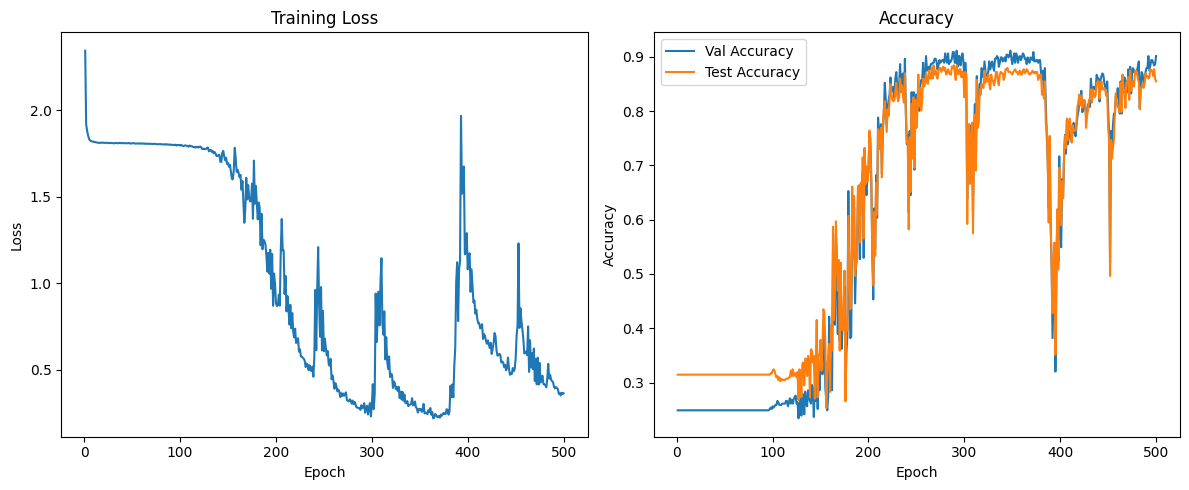

In [14]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, val_accs, label="Val Accuracy")
plt.plot(epochs, test_accs, label="Test Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()